<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/Pubchem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv('/content/Pubchem.csv')
data

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,bioactivity_class
0,CHEMBL167155,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1,CHEMBL166740,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
2,CHEMBL165038,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
3,CHEMBL435857,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
4,CHEMBL352783,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1225,CHEMBL5436920,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1226,CHEMBL5405698,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1227,CHEMBL5416562,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [ ]:
data.dtypes

,0
Name,object
PubchemFP0,int64
PubchemFP1,int64
PubchemFP2,int64
PubchemFP3,int64
...,...
PubchemFP877,int64
PubchemFP878,int64
PubchemFP879,int64
PubchemFP880,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-3-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-3-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,class
0,CHEMBL167155,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1,CHEMBL166740,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
2,CHEMBL165038,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
3,CHEMBL435857,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
4,CHEMBL352783,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,CHEMBL5436920,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,CHEMBL5416562,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:882]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,...,PubchemFP779,PubchemFP784,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP803,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,1,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1225,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1226,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1227,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,...,PubchemFP784,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP803,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824,class
0,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
1,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
2,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
3,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
4,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,1,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,N
1225,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
1226,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
1227,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,N


In [ ]:
## remove features that display high correlation with many other features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.9:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1

{'PubchemFP188',
 'PubchemFP285',
 'PubchemFP287',
 'PubchemFP293',
 'PubchemFP294',
 'PubchemFP342',
 'PubchemFP351',
 'PubchemFP353',
 'PubchemFP362',
 'PubchemFP365',
 'PubchemFP382',
 'PubchemFP387',
 'PubchemFP393',
 'PubchemFP403',
 'PubchemFP406',
 'PubchemFP418',
 'PubchemFP422',
 'PubchemFP431',
 'PubchemFP435',
 'PubchemFP442',
 'PubchemFP443',
 'PubchemFP445',
 'PubchemFP447',
 'PubchemFP449',
 'PubchemFP450',
 'PubchemFP451',
 'PubchemFP452',
 'PubchemFP453',
 'PubchemFP457',
 'PubchemFP459',
 'PubchemFP465',
 'PubchemFP467',
 'PubchemFP472',
 'PubchemFP477',
 'PubchemFP482',
 'PubchemFP484',
 'PubchemFP487',
 'PubchemFP491',
 'PubchemFP498',
 'PubchemFP499',
 'PubchemFP501',
 'PubchemFP504',
 'PubchemFP506',
 'PubchemFP507',
 'PubchemFP515',
 'PubchemFP519',
 'PubchemFP523',
 'PubchemFP530',
 'PubchemFP531',
 'PubchemFP538',
 'PubchemFP540',
 'PubchemFP541',
 'PubchemFP542',
 'PubchemFP545',
 'PubchemFP546',
 'PubchemFP549',
 'PubchemFP550',
 'PubchemFP555',
 'PubchemFP560

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,...,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819,class
0,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
1,1,0,1,0,1,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,N
2,1,0,1,0,1,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,N
3,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
4,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,1,0,1,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,N
1225,0,0,1,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,N
1226,0,0,1,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,N
1227,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,N


In [ ]:
data3.to_csv('PubChem2.csv')

In [ ]:
X = data3.iloc[:,1:166]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X

,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,...,PubchemFP737,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819
0,0,1,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,1,0,1,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,1,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,1,0,1,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
1225,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1226,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1227,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,...,PubchemFP737,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819
0,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,0.427631,1.000814,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,-0.512936,-0.660112,-0.541926,-0.639847,-0.543183,-0.577037
1,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,0.427631,1.000814,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,1.949559,-0.660112,-0.541926,-0.639847,-0.543183,-0.577037
2,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,0.427631,1.000814,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,1.949559,-0.660112,-0.541926,-0.639847,-0.543183,-0.577037
3,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,0.427631,1.000814,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,-0.512936,-0.660112,-0.541926,-0.639847,-0.543183,-0.577037
4,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,0.427631,1.000814,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,-0.512936,-0.660112,-0.541926,-0.639847,-0.543183,-0.577037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.501525,0.365737,-0.393796,0.402027,0.629755,-0.939193,-2.338466,-0.999187,-0.477255,-0.377085,...,-0.399292,2.353133,-0.495164,1.983871,-0.512936,-0.660112,-0.541926,-0.639847,1.841001,-0.577037
1225,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,-2.338466,-0.999187,-0.477255,-0.377085,...,-0.399292,2.353133,-0.495164,-0.504065,1.949559,-0.660112,-0.541926,-0.639847,1.841001,-0.577037
1226,-0.501525,0.365737,-0.393796,0.402027,-1.587920,-0.939193,-2.338466,-0.999187,-0.477255,-0.377085,...,-0.399292,2.353133,-0.495164,-0.504065,-0.512936,-0.660112,-0.541926,-0.639847,1.841001,-0.577037
1227,-0.501525,-2.734202,-0.393796,-2.487395,-1.587920,-0.939193,0.427631,-0.999187,-0.477255,-0.377085,...,-0.399292,-0.424965,-0.495164,-0.504065,-0.512936,1.514895,-0.541926,1.562875,-0.543183,-0.577037


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(860, 165)
(860,)
(369, 165)
(369,)


In [ ]:
X_train

,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,...,PubchemFP737,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819
387,0,1,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,1,0,0,1
250,0,1,0,1,1,1,1,0,1,1,...,1,0,0,1,1,0,0,0,0,0
378,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
73,0,1,0,1,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1185,0,1,0,1,1,1,1,1,0,0,...,0,0,1,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,1,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1180,1,1,0,1,1,1,1,1,0,0,...,0,0,1,1,0,1,1,0,0,1
1147,0,1,0,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
527,0,1,0,1,1,1,1,1,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,...,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819,class
387,0,1,0,1,1,0,0,0,0,0,...,0,1,1,0,0,1,0,0,1,N
250,0,1,0,1,1,1,1,0,1,1,...,0,0,1,1,0,0,0,0,0,N
378,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,N
73,0,1,0,1,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,N
1185,0,1,0,1,1,1,1,1,0,0,...,0,1,1,0,1,1,0,0,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,1,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1180,1,1,0,1,1,1,1,1,0,0,...,0,1,1,0,1,1,0,0,1,P
1147,0,1,0,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,N
527,0,1,0,1,1,1,1,1,0,0,...,0,1,0,1,0,0,0,0,1,P


In [ ]:
Training_set.to_csv('PubChem_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP24,...,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP776,PubchemFP777,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819,class
693,1,1,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,N
834,0,1,0,1,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,N
1016,0,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,1,0,0,P
1113,0,1,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,1,0,0,P
31,0,1,0,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,0,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,P
909,1,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,P
270,0,1,0,1,1,1,1,0,1,1,...,0,0,1,1,0,0,0,0,0,N
349,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,1,0,0,0,0,P


In [ ]:
Testing_set.to_csv('PubChem_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape

(860, 15)

In [ ]:
kBest.get_support(True)

array([ 23,  29,  32,  33,  67,  96, 101, 108, 114, 121, 122, 123, 144,
       145, 158])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['PubchemFP187', 'PubchemFP258', 'PubchemFP299', 'PubchemFP300',
       'PubchemFP397', 'PubchemFP567', 'PubchemFP577', 'PubchemFP601',
       'PubchemFP621', 'PubchemFP639', 'PubchemFP643', 'PubchemFP646',
       'PubchemFP700', 'PubchemFP702', 'PubchemFP758'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores

,Features,Scores
0,PubchemFP3,0.010513
1,PubchemFP12,0.003215
2,PubchemFP13,0.000281
3,PubchemFP14,0.008888
4,PubchemFP15,0.001744
...,...,...
160,PubchemFP777,0.013720
161,PubchemFP797,0.000000
162,PubchemFP798,0.001864
163,PubchemFP818,0.030979


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

         Features    Scores
67   PubchemFP397  0.053142
33   PubchemFP300  0.049272
122  PubchemFP643  0.046308
23   PubchemFP187  0.045285
123  PubchemFP646  0.044045
145  PubchemFP702  0.041193
32   PubchemFP299  0.040073
29   PubchemFP258  0.039272
108  PubchemFP601  0.039121
158  PubchemFP758  0.035370
114  PubchemFP621  0.034293
144  PubchemFP700  0.033932
121  PubchemFP639  0.033690
96   PubchemFP567  0.032235
101  PubchemFP577  0.031916


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
67,PubchemFP397,0.053142
33,PubchemFP300,0.049272
122,PubchemFP643,0.046308
23,PubchemFP187,0.045285
123,PubchemFP646,0.044045
145,PubchemFP702,0.041193
32,PubchemFP299,0.040073
29,PubchemFP258,0.039272
108,PubchemFP601,0.039121
158,PubchemFP758,0.035370


In [ ]:
Graph.to_csv('Pubchem_Features.csv')

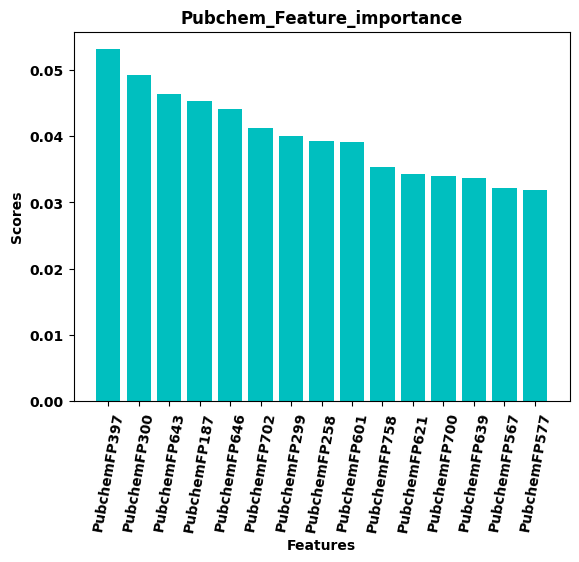

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('Pubchem_Features.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("Pubchem_Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,PubchemFP187,PubchemFP258,PubchemFP299,PubchemFP300,PubchemFP397,PubchemFP567,PubchemFP577,PubchemFP601,PubchemFP621,PubchemFP639,PubchemFP643,PubchemFP646,PubchemFP700,PubchemFP702,PubchemFP758,class
387,0,1,1,0,0,0,1,1,1,0,1,0,0,1,1,N
250,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1,N
378,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,N
73,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,N
1185,0,0,1,0,0,0,1,0,0,0,1,1,1,1,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,N
1180,1,0,1,0,0,0,1,0,0,0,1,1,1,1,1,P
1147,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,N
527,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,PubchemFP187,PubchemFP258,PubchemFP299,PubchemFP300,PubchemFP397,PubchemFP567,PubchemFP577,PubchemFP601,PubchemFP621,PubchemFP639,PubchemFP643,PubchemFP646,PubchemFP700,PubchemFP702,PubchemFP758
693,1,0,1,0,0,0,0,1,1,0,1,1,0,1,0
834,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0
1016,0,1,1,0,0,0,1,0,0,1,1,0,1,0,0
1113,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
31,0,0,1,0,0,0,1,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,1,1,0,0,0,1,1,1,0,1,0,0,0,0
909,1,1,1,0,0,0,1,0,0,0,1,1,0,0,0
270,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1
349,0,0,1,0,0,0,0,0,0,0,1,1,1,1,0


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,PubchemFP187,PubchemFP258,PubchemFP299,PubchemFP300,PubchemFP397,PubchemFP567,PubchemFP577,PubchemFP601,PubchemFP621,PubchemFP639,PubchemFP643,PubchemFP646,PubchemFP700,PubchemFP702,PubchemFP758,class
693,1,0,1,0,0,0,0,1,1,0,1,1,0,1,0,N
834,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,N
1016,0,1,1,0,0,0,1,0,0,1,1,0,1,0,0,P
1113,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,P
31,0,0,1,0,0,0,1,1,0,0,1,0,0,0,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,1,1,0,0,0,1,1,1,0,1,0,0,0,0,P
909,1,1,1,0,0,0,1,0,0,0,1,1,0,0,0,P
270,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1,N
349,0,0,1,0,0,0,0,0,0,0,1,1,1,1,0,P


In [ ]:
Trainset.to_csv('Trainset_Pubchem_after_feature.csv')
Testset.to_csv('Testset_Pubchem_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-38-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-38-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,PubchemFP187,PubchemFP258,PubchemFP299,PubchemFP300,PubchemFP397,PubchemFP567,PubchemFP577,PubchemFP601,PubchemFP621,PubchemFP639,PubchemFP643,PubchemFP646,PubchemFP700,PubchemFP702,PubchemFP758,class
387,0,1,1,0,0,0,1,1,1,0,1,0,0,1,1,0
250,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1,0
378,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0
73,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0
1185,0,0,1,0,0,0,1,0,0,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1180,1,0,1,0,0,0,1,0,0,0,1,1,1,1,1,1
1147,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0
527,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-39-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-39-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,PubchemFP187,PubchemFP258,PubchemFP299,PubchemFP300,PubchemFP397,PubchemFP567,PubchemFP577,PubchemFP601,PubchemFP621,PubchemFP639,PubchemFP643,PubchemFP646,PubchemFP700,PubchemFP702,PubchemFP758,class
693,1,0,1,0,0,0,0,1,1,0,1,1,0,1,0,0
834,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0
1016,0,1,1,0,0,0,1,0,0,1,1,0,1,0,0,1
1113,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1
31,0,0,1,0,0,0,1,1,0,0,1,0,0,0,1,1


In [ ]:
Trainset.to_csv('Trainset1_Pubchem_after_feature.csv')
Testset.to_csv('Testset1_Pubchem_after_feature.csv')